<a href="https://colab.research.google.com/github/Khoi123345/NCKH/blob/main/NCKH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/BLIP

Mounted at /content/drive
/content/drive/MyDrive/BLIP


In [3]:
!pip install transformers timm torch pillow cog
!pip install ruamel.yaml
!pip install transformers==4.16.2
!pip install timm==0.4.12
!pip install fairscale==0.4.4
# gỡ cài đặt cũ nếu có
!pip uninstall -y pycocoevalcap

# cài đặt
!pip install .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 63.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.1

Dataset VQAv2 (không chạy)

In [ ]:
import os
os.makedirs('/content/coco_images', exist_ok=True)

# 1. Tải & giải nén COCO train2014 (~13GB zip, ~83K ảnh)
!wget http://images.cocodataset.org/zips/train2014.zip -P /content/coco_images/
!unzip -q /content/coco_images/train2014.zip -d /content/coco_images/
!rm /content/coco_images/train2014.zip

# 2. Tải & giải nén COCO val2014 (~6GB zip, ~40K ảnh)
!wget http://images.cocodataset.org/zips/val2014.zip -P /content/coco_images/
!unzip -q /content/coco_images/val2014.zip -d /content/coco_images/
!rm /content/coco_images/val2014.zip

# 3. Tải & giải nén COCO test2015 (~12GB zip, ~81K ảnh)
!wget http://images.cocodataset.org/zips/test2015.zip -P /content/coco_images/
!unzip -q /content/coco_images/test2015.zip -d /content/coco_images/
!rm /content/coco_images/test2015.zip

--2026-03-03 15:11:06--  http://images.cocodataset.org/zips/train2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.30.180, 52.216.220.129, 16.182.107.161, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.30.180|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13510573713 (13G) [application/zip]
Saving to: ‘/content/coco_images/train2014.zip’

train2014.zip       100%[===================>]  12.58G  48.6MB/s    in 4m 12s  

2026-03-03 15:15:18 (51.2 MB/s) - ‘/content/coco_images/train2014.zip’ saved [13510573713/13510573713]

--2026-03-03 15:17:33--  http://images.cocodataset.org/zips/val2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.86.4, 3.5.31.183, 16.15.216.223, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.86.4|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6645013297 (6.2G) [application/zip]
Saving to: ‘/content/coco_images/val2014.

# TextVQA (phải chạy)

---



In [4]:
 # Tạo thư mục chứa dữ liệu
!mkdir -p /content/textvqa

# Tải annotation (train, val, test)
!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5_train.json -O /content/textvqa/TextVQA_train.json
!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5_val.json -O /content/textvqa/TextVQA_val.json
!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5_test.json -O /content/textvqa/TextVQA_test.json

--2026-07-07 04:50:37--  https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5_train.json
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.4, 65.9.168.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 107289766 (102M) [text/plain]
Saving to: ‘/content/textvqa/TextVQA_train.json’

/content/textvqa/Te 100%[===================>] 102.32M  21.7MB/s    in 5.8s    

2026-07-07 04:50:44 (17.5 MB/s) - ‘/content/textvqa/TextVQA_train.json’ saved [107289766/107289766]

--2026-07-07 04:50:44--  https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5_val.json
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.4, 65.9.168.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15782960 (15M) [text/plain]
Saving to: ‘/content/textv

In [5]:
!wget https://dl.fbaipublicfiles.com/textvqa/images/train_val_images.zip -O /content/textvqa/train_val_images.zip
!unzip -q /content/textvqa/train_val_images.zip -d /content/textvqa/

--2026-07-07 04:50:49--  https://dl.fbaipublicfiles.com/textvqa/images/train_val_images.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.4, 65.9.168.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7072297970 (6.6G) [application/zip]
Saving to: ‘/content/textvqa/train_val_images.zip’

/content/textvqa/tr 100%[===================>]   6.59G   201MB/s    in 40s     

2026-07-07 04:51:29 (168 MB/s) - ‘/content/textvqa/train_val_images.zip’ saved [7072297970/7072297970]



# Train TextVQA


In [ ]:
!python train_vqa.py \
    --config ./configs/textvqa.yaml \
    --output_dir ./output/textVQA \
    --device cuda \
    --distributed False \
    --resume ./output/textVQA/checkpoint_04.pth

Not using distributed mode
Creating vqa datasets
>>> Check dataset size:
Train dataset size: 34602
Val dataset size: 5000
Creating model
Downloading: 100% 48.0/48.0 [00:00<00:00, 318kB/s]
Downloading: 100% 226k/226k [00:00<00:00, 2.84MB/s]
Downloading: 100% 455k/455k [00:00<00:00, 2.26MB/s]
Downloading: 100% 570/570 [00:00<00:00, 4.30MB/s]
100% 1.35G/1.35G [00:36<00:00, 39.2MB/s]
reshape position embedding from 900 to 196
load checkpoint from https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_vqa_capfilt_large.pth
<All keys matched successfully>
=> loading checkpoint './output/textVQA/checkpoint_04.pth'
=> loaded checkpoint './output/textVQA/checkpoint_04.pth' (epoch 5)
Start training
Loss: 5.8001
Train Epoch: [5]  [   0/8650]  eta: 13:56:33  lr: 0.000019  loss: 5.8001  time: 5.8027  data: 1.8266  max mem: 6922
Loss: 9.716
Loss: 6.8981
Loss: 11.0914
Loss: 7.5408
Loss: 8.2925
Loss: 7.6599
Loss: 7.5884
Loss: 7.7234
Loss: 11.2942
Loss: 10.0351
Loss: 9.1664


# Train textVQA + pretrain_animal

In [ ]:
!python train_vqa.py \
    --config ./configs/textvqa_animals.yaml \
    --output_dir ./output/textVQA_pretrain_animals \
    --device cuda \
    --distributed False \
    --resume ./output/textVQA_pretrain_animals/checkpoint_16.pth

Not using distributed mode
Creating vqa datasets
>>> Check dataset size:
Train dataset size: 34602
Val dataset size: 5000
Creating model
Downloading: 100% 48.0/48.0 [00:00<00:00, 277kB/s]
Downloading: 100% 226k/226k [00:00<00:00, 774kB/s]
Downloading: 100% 455k/455k [00:00<00:00, 4.62MB/s]
Downloading: 100% 570/570 [00:00<00:00, 4.86MB/s]
load checkpoint from /content/drive/MyDrive/BLIP/output/pretrain_animals/checkpoint_29.pth
_IncompatibleKeys(missing_keys=[], unexpected_keys=['temp', 'image_queue', 'text_queue', 'queue_ptr', 'vision_proj.weight', 'vision_proj.bias', 'text_proj.weight', 'text_proj.bias', 'itm_head.weight', 'itm_head.bias', 'visual_encoder_m.cls_token', 'visual_encoder_m.pos_embed', 'visual_encoder_m.patch_embed.proj.weight', 'visual_encoder_m.patch_embed.proj.bias', 'visual_encoder_m.blocks.0.norm1.weight', 'visual_encoder_m.blocks.0.norm1.bias', 'visual_encoder_m.blocks.0.attn.qkv.weight', 'visual_encoder_m.blocks.0.attn.qkv.bias', 'visual_encoder_m.blocks.0.attn.pr

# Train Textvqa + PretrainTextCaps

In [ ]:
!python train_vqa.py \
    --config ./configs/textvqa_Textcaps.yaml \
    --output_dir ./output/textVQA_pretrain_textcaps \
    --device cuda \
    --distributed False \
    --resume ./output/textVQA_pretrain_textcaps/checkpoint_07.pth

# Train TextVQA + resnet

In [ ]:
!python train_vqa.py \
    --config ./configs/resnet_textvqa.yaml \
    --output_dir ./output/resnet_textvqa \
    --device cuda \
    --distributed False \
    --resume ./output/resnet_textvqa/checkpoint_18.pth

Train VQA + dataset VQAv2 (không chạy)

In [ ]:
import json
from collections import Counter

# Đọc annotation train
ann = []
for f in ['vqa_train.json', 'vqa_val.json']:
    ann += json.load(open(f'/content/drive/MyDrive/BLIP/annotation/{f}', 'r'))

# Đếm tần suất tất cả answers
answer_counter = Counter()
for item in ann:
    if 'answer' in item:
        if isinstance(item['answer'], list):
            for a in item['answer']:
                answer_counter[a] += 1
        else:
            answer_counter[a] += 1

# Lấy top 3129 answers (đúng chuẩn BLIP gốc)
top_answers = [ans for ans, _ in answer_counter.most_common(3129)]
print(f"Total unique answers: {len(answer_counter)}")
print(f"Selected top answers: {len(top_answers)}")
print(f"Top 10: {top_answers[:10]}")

# Lưu
with open('/content/drive/MyDrive/BLIP/annotation/answer_list.json', 'w') as f:
    json.dump(top_answers, f)

print("Saved answer_list.json!")

Total unique answers: 208351
Selected top answers: 3129
Top 10: ['no', 'yes', '2', '1', 'white', '3', 'red', 'black', 'blue', '0']
Saved answer_list.json!


In [ ]:
!python train_vqa_v2.py --config ./configs/vqa.yaml --output_dir output/VQA --distributed False

Not using distributed mode
Creating vqa datasets
>>> Check dataset size:
Train dataset size: 658104
Val dataset size: 447793
Creating model
reshape position embedding from 900 to 196
load checkpoint from https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_vqa_capfilt_large.pth
<All keys matched successfully>
Start training
Loss: 4.4719
Train Epoch: [0]  [    0/82263]  eta: 2 days, 7:46:50  lr: 0.000020  loss: 4.4719  time: 2.4411  data: 0.5341  max mem: 6926
Loss: 3.4943
Loss: 5.2282
Loss: 5.6852
Loss: 5.1765
Loss: 4.9297
Loss: 6.7231
Loss: 4.8258
Loss: 5.9579
Loss: 3.6883
Loss: 4.5728
Loss: 3.4673
Loss: 3.3514
Loss: 3.7705
Loss: 5.4413
Loss: 4.5754
Loss: 3.2904
Loss: 4.27
Loss: 6.3744
Loss: 3.6578
Loss: 5.5287
Loss: 4.0344
Loss: 4.854
Loss: 4.8066
Loss: 4.2456
Loss: 4.7849
Loss: 3.6546
Loss: 6.4833
Loss: 4.4005
Loss: 4.0618
Loss: 4.7003
Loss: 5.0915
Loss: 5.2761
Loss: 4.3771
Loss: 6.8743
Loss: 4.4175
Loss: 6.3432
Loss: 3.5996
Loss: 4.531
Loss: 4.4852
Los

# Pretrain với resnet (textcaps)

In [ ]:
!wget https://dl.fbaipublicfiles.com/textvqa/images/train_val_images.zip -O /content/drive/MyDrive/BLIP/textcaps/train_val_images.zip
!unzip -q /content/drive/MyDrive/BLIP/textcaps/train_val_images.zip -d /content/drive/MyDrive/BLIP/textcaps/

--2026-03-14 14:25:34--  https://dl.fbaipublicfiles.com/textvqa/images/train_val_images.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.33, 13.249.182.39, 13.249.182.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7072297970 (6.6G) [application/zip]
Saving to: ‘/content/drive/MyDrive/BLIP/textcaps/train_val_images.zip’

/content/drive/MyDr 100%[===================>]   6.59G  54.9MB/s    in 2m 6s   

2026-03-14 14:27:40 (53.5 MB/s) - ‘/content/drive/MyDrive/BLIP/textcaps/train_val_images.zip’ saved [7072297970/7072297970]



In [ ]:
!python pretrain.py \
  --config ./configs/pretrain_resnet.yaml \
  --output_dir output/pretrain_resnet50 \
  --distributed False \
  --checkpoint output/pretrain_resnet50/checkpoint_10.pth

Not using distributed mode
Creating dataset
Đang tải dữ liệu từ: /content/drive/MyDrive/BLIP/textcaps/textcaps_pretrain.json
number of training samples: 21953
Creating model
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 184MB/s]
Downloading: 100% 48.0/48.0 [00:00<00:00, 297kB/s]
Downloading: 226kB [00:00, 874kB/s]
Downloading: 455kB [00:00, 1.50MB/s]
Downloading: 100% 570/570 [00:00<00:00, 3.80MB/s]
Downloading: 100% 420M/420M [00:06<00:00, 72.2MB/s]
/embeddings/word_embeddings is tied
/embeddings/position_embeddings is tied
/embeddings/LayerNorm is tied
/encoder/layer/0/crossattention/self/query is tied
/encoder/layer/0/crossattention/self/key is tied
/encoder/layer/0/crossattention/self/value is tied
/encoder/layer/0/crossattention/output/dense is tied
/encoder/layer/0/crossattention/output/LayerNorm is tied
/encoder/layer/0/intermediate/dense is tied
/encoder/layer/0

# **Pretrain với DISTILBERT** (textcaps)

In [ ]:
!python pretrain_custom_distilbert.py \
  --config ./configs/pretrain_distilbert.yaml \
  --output_dir output/pretrain_distilBert\
  --distributed False \
  --checkpoint /output/pretrain_distilBert/checkpoint_10.pth

Not using distributed mode
Creating dataset
Đang tải dữ liệu từ: /content/drive/MyDrive/BLIP/textcaps/textcaps_pretrain.json
number of training samples: 21953
Creating model
/embeddings/word_embeddings is tied
/embeddings/position_embeddings is tied
/embeddings/LayerNorm is tied
/transformer/layer/0/sa_layer_norm is tied
/transformer/layer/0/crossattention/q_lin is tied
/transformer/layer/0/crossattention/k_lin is tied
/transformer/layer/0/crossattention/v_lin is tied
/transformer/layer/0/crossattention/out_lin is tied
/transformer/layer/0/ca_layer_norm is tied
/transformer/layer/0/ffn/lin1 is tied
/transformer/layer/0/ffn/lin2 is tied
/transformer/layer/0/output_layer_norm is tied
/transformer/layer/1/sa_layer_norm is tied
/transformer/layer/1/crossattention/q_lin is tied
/transformer/layer/1/crossattention/k_lin is tied
/transformer/layer/1/crossattention/v_lin is tied
/transformer/layer/1/crossattention/out_lin is tied
/transformer/layer/1/ca_layer_norm is tied
/transformer/layer/1/

# **Train_vqa_distilBERT**

In [ ]:
!python train_vqa_custom_distilbert.py \
  --config ./configs/vqa_distilbert.yaml \
  --output_dir output/train_distilbert_textVQA \
  --distributed False \
  --checkpoint output/train_distilbert_textVQA/checkpoint_00.pth

usage: train_vqa_custom_distilbert.py [-h] [--config CONFIG]
                                      [--output_dir OUTPUT_DIR] [--evaluate]
                                      [--device DEVICE] [--seed SEED]
                                      [--world_size WORLD_SIZE]
                                      [--dist_url DIST_URL]
                                      [--distributed DISTRIBUTED]
                                      [--checkpoint CHECKPOINT]
train_vqa_custom_distilbert.py: error: unrecognized arguments: --checkpointoutput/train_distilbert_textVQA/checkpoint_00.pth


# **Pretrain**

Nếu bạn đã mount Google Drive của mình, bạn có thể sử dụng lệnh sau để giải nén một tệp tin zip từ Drive vào Colab. Hãy thay thế `'/content/drive/MyDrive/path/to/your_file.zip'` bằng đường dẫn thực tế đến tệp zip của bạn và `'/content/destination_folder'` bằng thư mục bạn muốn giải nén đến.

In [ ]:
# Ví dụ: Giải nén một tệp tin zip từ Google Drive
# Tạo thư mục đích nếu nó chưa tồn tại
!mkdir -p /content/dataset_animals

# Giải nén tệp tin
!unzip -q '/content/drive/MyDrive/Datasets_BLIP/coco_animals_blip_ready.zip' -d '/content/dataset_animals'

In [ ]:
!ls -a /content/dataset_animals

In [ ]:
!python pretrain.py --config configs/pre_animals.yaml --output_dir output/pretrain_animals --checkpoint output/pretrain_animals/checkpoint_22.pth

Not using distributed mode
Creating dataset
Đang tải dữ liệu từ: /content/dataset_animals/dataset.json
number of training samples: 20000
Creating model
/embeddings/word_embeddings is tied
/embeddings/position_embeddings is tied
/embeddings/LayerNorm is tied
/encoder/layer/0/crossattention/self/query is tied
/encoder/layer/0/crossattention/self/key is tied
/encoder/layer/0/crossattention/self/value is tied
/encoder/layer/0/crossattention/output/dense is tied
/encoder/layer/0/crossattention/output/LayerNorm is tied
/encoder/layer/0/intermediate/dense is tied
/encoder/layer/0/output/dense is tied
/encoder/layer/0/output/LayerNorm is tied
/encoder/layer/1/crossattention/self/query is tied
/encoder/layer/1/crossattention/self/key is tied
/encoder/layer/1/crossattention/self/value is tied
/encoder/layer/1/crossattention/output/dense is tied
/encoder/layer/1/crossattention/output/LayerNorm is tied
/encoder/layer/1/intermediate/dense is tied
/encoder/layer/1/output/dense is tied
/encoder/layer

# Eval_vqa

In [ ]:
!python eval_vqa.py \
  --config ./configs/textvqa_Textcaps.yaml \
  --checkpoint /content/drive/MyDrive/BLIP/output/textVQA_pretrain_textcaps/checkpoint_29.pth \
  --ann_file /content/textvqa/TextVQA_val.json \
  --answer_list_file /content/drive/MyDrive/BLIP/annotation/answer_list_textvqa.json \
  --output_dir output/textVQA_pretrain_textcaps_eval

Not using distributed mode
Creating model: blip
load checkpoint from /content/drive/MyDrive/BLIP/output/PretrainTextcaps/checkpoint_29.pth
_IncompatibleKeys(missing_keys=[], unexpected_keys=['temp', 'image_queue', 'text_queue', 'queue_ptr', 'vision_proj.weight', 'vision_proj.bias', 'text_proj.weight', 'text_proj.bias', 'itm_head.weight', 'itm_head.bias', 'visual_encoder_m.cls_token', 'visual_encoder_m.pos_embed', 'visual_encoder_m.patch_embed.proj.weight', 'visual_encoder_m.patch_embed.proj.bias', 'visual_encoder_m.blocks.0.norm1.weight', 'visual_encoder_m.blocks.0.norm1.bias', 'visual_encoder_m.blocks.0.attn.qkv.weight', 'visual_encoder_m.blocks.0.attn.qkv.bias', 'visual_encoder_m.blocks.0.attn.proj.weight', 'visual_encoder_m.blocks.0.attn.proj.bias', 'visual_encoder_m.blocks.0.norm2.weight', 'visual_encoder_m.blocks.0.norm2.bias', 'visual_encoder_m.blocks.0.mlp.fc1.weight', 'visual_encoder_m.blocks.0.mlp.fc1.bias', 'visual_encoder_m.blocks.0.mlp.fc2.weight', 'visual_encoder_m.blocks.

BLIP + dataset TextVQA

In [ ]:
!python eval_vqa.py \
  --result_file output/textVQA/result/vqa_result.json \
  --ann_file /content/textvqa/TextVQA_val.json


VQA ACCURACY RESULTS
Total questions evaluated : 5000
Exact match accuracy      : 18.02%
VQA soft score            : 16.58%

Metrics saved to output/textVQA/result/vqa_metrics.json


Resnet + dataset TextVQA (pretrain textcaps)

In [ ]:
!python eval_vqa.py \
  --result_file output/resnet_textvqa/result/vqa_result.json \
  --ann_file /content/textvqa/TextVQA_val.json


VQA ACCURACY RESULTS
Total questions evaluated : 5000
Exact match accuracy      : 12.56%
VQA soft score            : 11.49%

Metrics saved to output/resnet_textvqa/result/vqa_metrics.json


BLIP + textVQA (pretrain Textcaps)

In [ ]:
!python eval_vqa.py \
  --result_file output/textVQA_pretrain_textcaps/result/vqa_result.json \
  --ann_file /content/textvqa/TextVQA_val.json


VQA ACCURACY RESULTS
Total questions evaluated : 5000
Exact match accuracy      : 2.30%
VQA soft score            : 1.97%

Metrics saved to output/textVQA_pretrain_textcaps/result/vqa_metrics.json


DistillBERT + textVQA

In [ ]:
!python eval_vqa.py \
  --result_file output/train_distilbert_textVQA/result/vqa_result.json \
  --ann_file /content/textvqa/TextVQA_val.json


VQA ACCURACY RESULTS
Total questions evaluated : 5000
Exact match accuracy      : 4.84%
VQA soft score            : 3.12%

Metrics saved to output/train_distilbert_textVQA/result/vqa_metrics.json


Demo

In [11]:
import torch
import io
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
from models.blip_vqa import blip_vqa
from data.utils import pre_question

# ⚠️ SỬA ĐƯỜNG DẪN CHECKPOINT CỦA BẠN TẠI ĐÂY
CHECKPOINT_PATH = '/content/drive/MyDrive/BLIP/output/textVQA/checkpoint_29.pth'
image_size = 224
vit_type = 'base'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\n⏳ Đang khởi tạo mô hình (Chỉ mất thời gian ở lần chạy này)...")

model = blip_vqa(pretrained='', image_size=image_size, vit=vit_type)

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state_dict = checkpoint.get("model", checkpoint)
cleaned_state_dict = {k[7:] if k.startswith("module.") else k: v for k, v in state_dict.items()}

model.load_state_dict(cleaned_state_dict, strict=False)
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

print(f"✅ Mô hình đã load xong trên {str(device).upper()}! Bây giờ bạn hãy chạy Cell 2 bên dưới.")


⏳ Đang khởi tạo mô hình (Chỉ mất thời gian ở lần chạy này)...
✅ Mô hình đã load xong trên CUDA! Bây giờ bạn hãy chạy Cell 2 bên dưới.


🖼️ Vui lòng tải lên 1 bức ảnh để test:


Saving m10.webp to m10.webp


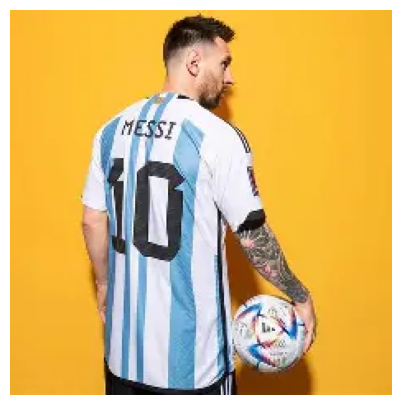


💡 MẸO: Bạn có thể hỏi nhiều câu liên tục. Gõ chữ 'exit' hoặc để trống rồi Enter để thoát và tải ảnh mới.

❓ Nhập câu hỏi tiếng Anh: What name is printed across the top of the jersey?
--------------------------------------------------
🤖 Trả lời: zero
--------------------------------------------------

❓ Nhập câu hỏi tiếng Anh: What large number is shown on the back of the player's shirt?
--------------------------------------------------
🤖 Trả lời: 10
--------------------------------------------------

❓ Nhập câu hỏi tiếng Anh: What is the name on the shirt?
--------------------------------------------------
🤖 Trả lời: messi
--------------------------------------------------


KeyboardInterrupt: Interrupted by user

In [16]:
# 2. TẢI ẢNH LÊN VÀ HỎI ĐÁP (CÓ THỂ HỎI NHIỀU LẦN CHO CÙNG 1 ẢNH)

print("🖼️ Vui lòng tải lên 1 bức ảnh để test:")
uploaded = files.upload()

if uploaded:
    filename = next(iter(uploaded))
    raw_image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

    # Hiển thị ảnh
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.axis('off')
    plt.show()

    # Xử lý ảnh 1 lần duy nhất để tiết kiệm thời gian
    image_tensor = transform(raw_image).unsqueeze(0).to(device)

    print("\n💡 MẸO: Bạn có thể hỏi nhiều câu liên tục. Gõ chữ 'exit' hoặc để trống rồi Enter để thoát và tải ảnh mới.")

    # Vòng lặp cho phép hỏi đi hỏi lại
    while True:
        question = input("\n❓ Nhập câu hỏi tiếng Anh: ")

        # Nếu nhập 'exit' hoặc để trống thì thoát vòng lặp
        if not question or question.strip().lower() == 'exit':
            print("👋 Đã kết thúc hỏi đáp cho bức ảnh này. Chạy lại Cell này nếu bạn muốn thử ảnh khác!")
            break

        processed_question = pre_question(question)

        # Chạy inference
        with torch.no_grad():
            answer = model(image_tensor, processed_question, train=False, inference="generate")

        print("-" * 50)
        print(f"🤖 Trả lời: {answer[0]}")
        print("-" * 50)
else:
    print("⚠️ Bạn chưa tải ảnh lên!")
